# 07 — Closing robustness checks: HAC/MBB SEs and GDELT coverage

Two final checks that close the loops left open by notebook 06.

**Check 5 — HAC and Moving-Block-Bootstrap SEs on $\gamma$.** Check 4 of notebook 06
identified only a handful of high-volatility episodes (long clustering). The
i.i.d.-style sandwich SEs reported in Checks 2–3 therefore overstate evidence
because the score $\partial \ell_t / \partial \gamma$ inherits the same serial
correlation. Here we recompute the SE on $\gamma$ with:
- **Newey–West HAC** at bandwidths $L \in \{25, 50, 75, 100\}$;
- **Moving-block bootstrap (Künsch, 1989) of the per-observation score** with
  block lengths $L \in \{25, 50, 75, 100\}$ and $B = 2{,}000$ replications.

If the *t*-ratio on $\gamma$ collapses below conventional thresholds once we
correct for serial dependence, the in-sample significance of $\gamma$
(particularly the t≈−4 to −6 reported for `log_art_growth` at $K=5,10,20$ in
Check 3) is mechanical — driven by the few volatility episodes — not a genuine
news effect.

**Check 6 — GDELT coverage of REMX / rare earths.** The cache assembled by
notebook 00 used a deliberately permissive `n_keywords ≥ 1` filter to keep
BigQuery costs down. Here we open that cache and ask the basic question:
how many of those articles actually pertain to a rare-earth topic versus
matching a single noisy concept (e.g. `cerium` appearing in an unrelated
chemistry article, or a tangential `lynas` hit). This is the empirical
foundation for the thesis's main limitation — that GDELT is too noisy for
a market this niche.


In [21]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from statsmodels.tools.numdiff import approx_hess
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

IN_PATH = '../CLEANED DATA/REMX_prices_sentiment_combined.xlsx'
df = (pd.read_excel(IN_PATH, parse_dates=['Date'])
        .sort_values('Date').reset_index(drop=True).set_index('Date'))
df['r'] = np.log(df['Close']/df['Close'].shift(1))
df['r'] = df['r'] - df['r'].mean()
df = df.dropna(subset=['r', 'tone_mean', 'log_art_growth', 'RV_rs']).copy()

r_pct    = df['r'].values * 100.0
tone     = df['tone_mean'].values
log_artg = df['log_art_growth'].values

KAPPA_HIGH = (50.0 / np.sqrt(252.0)) ** 2
SMOOTH_K   = 20.0
PARAM_NAMES = ['omega', 'alpha', 'beta', 'gamma', 'nu']
print(f'T = {len(df)} obs   κ_high = {KAPPA_HIGH:.4f} (%²/day)')

def _t_logpdf(z, nu):
    c = gammaln((nu+1)/2.0) - gammaln(nu/2.0) - 0.5*np.log(np.pi*(nu-2.0))
    return c - 0.5*(nu+1)*np.log1p(z**2/(nu-2.0))

def garchnd_ll(theta, r, x, kappa, smooth_k=SMOOTH_K):
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = 1.0/(1.0+np.exp(-smooth_k*(sig2[t-1]-kappa)))
        s  = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*d3*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r/np.sqrt(sig2)
    return _t_logpdf(z, nu) - 0.5*np.log(sig2), sig2

def neg_ll(theta, r, x, kappa, smooth_k=SMOOTH_K):
    return -garchnd_ll(theta, r, x, kappa, smooth_k)[0].sum()

def garchnd_fit(r, x, kappa, smooth_k=SMOOTH_K):
    x0 = np.array([0.086, 0.089, 0.898, 0.01, 8.0])
    bnd = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    opt  = minimize(neg_ll, x0,     args=(r, x, kappa, smooth_k),
                    method='L-BFGS-B', bounds=bnd, options={'maxiter': 5000})
    opt2 = minimize(neg_ll, opt.x, args=(r, x, kappa, smooth_k),
                    method='Nelder-Mead', options={'maxiter': 10000,
                                                   'xatol': 1e-7, 'fatol': 1e-7})
    if opt2.fun < opt.fun: opt = opt2
    return opt.x, -opt.fun

print('Refitting GARCHND κ=50% (x = tone) ...')
th_tone, ll_tone = garchnd_fit(r_pct, tone,     KAPPA_HIGH)
print(f'  γ̂ = {th_tone[3]:+.4f}   LL = {ll_tone:.2f}')

print('Refitting GARCHND κ=50% (x = log_art_growth) ...')
th_artg, ll_artg = garchnd_fit(r_pct, log_artg, KAPPA_HIGH)
print(f'  γ̂ = {th_artg[3]:+.4f}   LL = {ll_artg:.2f}')


T = 2765 obs   κ_high = 9.9206 (%²/day)
Refitting GARCHND κ=50% (x = tone) ...
  γ̂ = -1.0966   LL = -5950.47
Refitting GARCHND κ=50% (x = log_art_growth) ...
  γ̂ = -0.9972   LL = -5954.03


## Check 5 — HAC and Moving-Block-Bootstrap SEs on $\gamma$

**Sandwich logic.** With $\hat\theta$ the QMLE and $G_t = \partial \ell_t/\partial\theta$ evaluated at $\hat\theta$,
$$\sqrt{n}(\hat\theta - \theta_0) \xrightarrow{d} N\!\big(0,\; H^{-1} S\, H^{-1}\big), \quad H = -\mathbb{E}[\partial^2 \ell_t/\partial\theta\partial\theta'],\ S = \lim_{n\to\infty} \tfrac{1}{n}\mathrm{Var}\!\Big(\textstyle\sum_t G_t\Big).$$
The "robust" SEs in notebook 06 (and in Check 3) used $S \approx \sum_t G_t G_t^\top$, which assumes the scores are uncorrelated. They are not — the volatility-regime indicator $d_3$ stays active for tens of days during the few high-vol episodes identified in Check 4, mechanically inducing autocorrelation in $G_t$ at lag $\geq$ episode length.

**HAC.** Replace $S$ by the Newey–West / Bartlett estimator
$$\hat S_{\mathrm{NW}}(L) = \hat\Gamma_0 + \sum_{k=1}^{L}\!\Big(1 - \tfrac{k}{L+1}\Big)\big(\hat\Gamma_k + \hat\Gamma_k^\top\big),\quad \hat\Gamma_k = \sum_{t=k+1}^{n} G_t G_{t-k}^\top.$$
Reported for $L \in \{25, 50, 75, 100\}$ to bracket the longest cluster lengths found in Check 4.

**Moving-block bootstrap (Künsch, 1989).** Resample $\lceil n/L\rceil$ overlapping blocks of length $L$ from $\{G_1, \dots, G_n\}$ with replacement; for each draw $b$ compute $\sum_t G_t^{(b)}$. The bootstrap covariance across $B = 2{,}000$ draws is a non-parametric estimator of $S$ that preserves within-block serial dependence. Then $\widehat{\mathrm{Var}}(\hat\theta) = H^{-1}\,\widehat{\mathrm{Cov}}_{*}\!\!\left(\sum_t G_t^{(b)}\right) H^{-1}$.

We work on the *score* rather than refitting the full model on each bootstrap draw: this is the standard QMLE shortcut (Gonçalves & White 2004), avoids 2,000 refits, and gives the same first-order asymptotic correction. The exercise targets the lag-dependence in $S$, not the parameter resampling.

In [22]:
def per_obs_score(theta, r, x, kappa, smooth_k=SMOOTH_K, eps=1e-5):
    n, k = len(r), len(theta)
    G = np.empty((n, k))
    for i in range(k):
        up = theta.copy(); up[i] += eps
        dn = theta.copy(); dn[i] -= eps
        ll_up, _ = garchnd_ll(up, r, x, kappa, smooth_k)
        ll_dn, _ = garchnd_ll(dn, r, x, kappa, smooth_k)
        G[:, i] = (ll_up - ll_dn) / (2.0 * eps)
    return G

def hac_meat(G, L):
    S = G.T @ G
    for lag in range(1, L+1):
        w  = 1.0 - lag/(L+1.0)
        Gk = G[lag:].T @ G[:-lag]
        S += w * (Gk + Gk.T)
    return S

def mbb_meat(G, L, B=2000, seed=2026):
    rng = np.random.default_rng(seed)
    n, k = G.shape
    n_starts = n - L + 1
    n_blocks = int(np.ceil(n / L))
    block_offsets = np.arange(L)
    sums = np.empty((B, k))
    for b in range(B):
        starts = rng.integers(0, n_starts, size=n_blocks)
        idx = (starts[:, None] + block_offsets[None, :]).ravel()[:n]
        sums[b] = G[idx].sum(axis=0)
    return np.cov(sums.T, ddof=1)

def all_se(theta, r, x, kappa, L_list=(25, 50, 75, 100), B=2000, seed=2026):
    H     = approx_hess(theta, lambda p: neg_ll(p, r, x, kappa, SMOOTH_K))
    H_inv = np.linalg.inv(H)
    G     = per_obs_score(theta, r, x, kappa)
    out = {}
    # i.i.d. sandwich (baseline = Check 3 SEs)
    V = H_inv @ (G.T @ G) @ H_inv
    out['iid'] = np.sqrt(np.abs(np.diag(V)))
    # HAC
    for L in L_list:
        V = H_inv @ hac_meat(G, L) @ H_inv
        out[f'HAC L={L}'] = np.sqrt(np.abs(np.diag(V)))
    # MBB
    for L in L_list:
        V = H_inv @ mbb_meat(G, L, B=B, seed=seed) @ H_inv
        out[f'MBB L={L}'] = np.sqrt(np.abs(np.diag(V)))
    return out

def se_table(theta, ses, label):
    rows = []
    gamma = theta[3]
    for tag, se in ses.items():
        se_g = se[3]
        rows.append([tag, gamma, se_g, gamma/max(se_g, 1e-12)])
    tbl = pd.DataFrame(rows, columns=['SE method', 'γ̂', 'SE(γ)', 't(γ)'])
    print(f'\n=== {label} ===')
    print(tbl.to_string(index=False, float_format=lambda x: f'{x: .4f}'))
    return tbl

print('--- Computing HAC + MBB SEs for x = tone (B=2000) ---')
ses_tone = all_se(th_tone, r_pct, tone, KAPPA_HIGH)
tbl_tone = se_table(th_tone, ses_tone, 'GARCHND κ=50% tone')

print('\n--- Computing HAC + MBB SEs for x = log_art_growth (B=2000) ---')
ses_artg = all_se(th_artg, r_pct, log_artg, KAPPA_HIGH)
tbl_artg = se_table(th_artg, ses_artg, 'GARCHND κ=50% log_art_growth')

--- Computing HAC + MBB SEs for x = tone (B=2000) ---

=== GARCHND κ=50% tone ===
SE method      γ̂   SE(γ)    t(γ)
      iid -1.0966  0.1445 -7.5900
 HAC L=25 -1.0966  0.1360 -8.0623
 HAC L=50 -1.0966  0.1400 -7.8322
 HAC L=75 -1.0966  0.1413 -7.7592
HAC L=100 -1.0966  0.1411 -7.7705
 MBB L=25 -1.0966  0.1337 -8.2045
 MBB L=50 -1.0966  0.1416 -7.7427
 MBB L=75 -1.0966  0.1403 -7.8155
MBB L=100 -1.0966  0.1448 -7.5716

--- Computing HAC + MBB SEs for x = log_art_growth (B=2000) ---

=== GARCHND κ=50% log_art_growth ===
SE method      γ̂   SE(γ)    t(γ)
      iid -0.9972  0.1635 -6.1003
 HAC L=25 -0.9972  0.1444 -6.9065
 HAC L=50 -0.9972  0.1421 -7.0171
 HAC L=75 -0.9972  0.1453 -6.8618
HAC L=100 -0.9972  0.1458 -6.8413
 MBB L=25 -0.9972  0.1496 -6.6669
 MBB L=50 -0.9972  0.1469 -6.7864
 MBB L=75 -0.9972  0.1479 -6.7439
MBB L=100 -0.9972  0.1489 -6.6948


## Check 6 — GDELT coverage of REMX / rare earths

The article-level cache assembled in notebook 00 (`SentimentData_Aleix_REMX.csv`)
was pulled with `n_keywords ≥ 1` from a 19-concept dictionary. By construction
the cache is permissive: an article passes if **any single concept** matches.
Many concepts are noisy on their own — `cerium` appears in chemistry textbooks,
`samarium` in unrelated materials science, `lynas` is also a personal name,
`remx` can hit URL fragments unrelated to the ETF.

This check quantifies how many of the 314k cached articles plausibly pertain
to REMX/REE economics versus tangential / generic matches, under four
progressively tighter filter tiers:

1. **Broad** (= cache): $\geq 1$ concept.
2. **Medium**: any specific rare-earth metal OR any REMX-constituent company.
3. **Tight**: the `rare_earth` phrase AND a specific metal or company.
4. **Ultra-tight**: a specific metal AND a company (so the article ties an
   element to a producer — the most economically informative class).

For each tier we report total articles, share of the cache, daily counts and
the share of days with zero articles. The thinner the filter the more
informative each article — but also the larger the share of days with no
news, which then translate to forced-zero `tone_mean` and `log_art_growth`
inputs in the GARCHND model.

In [23]:
CSV = '../Sentiment data/SentimentData_Aleix_REMX.csv'
art = pd.read_csv(CSV)
art['date'] = pd.to_datetime(art['date_str'], format='%Y%m%d')
art = art.drop(columns='date_str')
print(f'Articles: {len(art):,}   days covered: {art["date"].nunique():,}')
print(f'Date range: {art["date"].min().date()} → {art["date"].max().date()}')

concept_cols = [c for c in art.columns if c.startswith('has_')]
print(f'\nArticles mentioning each concept (any-of, not mutually exclusive):')
print(f'{"concept":<28}{"N":>10}{"share":>10}')
for c in sorted(concept_cols, key=lambda c: -art[c].sum()):
    n = int(art[c].sum()); pct = 100*n/len(art)
    print(f'  {c:<26}{n:>10,}{pct:>9.2f}%')

Articles: 314,048   days covered: 4,000
Date range: 2015-04-01 → 2026-04-01

Articles mentioning each concept (any-of, not mutually exclusive):
concept                              N     share
  has_cerium                   186,346    59.34%
  has_rare_earth                92,383    29.42%
  has_lynas                     26,066     8.30%
  has_samarium                   5,005     1.59%
  has_neodymium                  2,960     0.94%
  has_mp_materials               2,891     0.92%
  has_praseodymium               2,124     0.68%
  has_arafura                    1,730     0.55%
  has_europium                   1,153     0.37%
  has_terbium                    1,143     0.36%
  has_gadolinium                 1,051     0.33%
  has_yttrium                    1,030     0.33%
  has_lanthanum                    877     0.28%
  has_china_northern               702     0.22%
  has_dysprosium                   576     0.18%
  has_ndfeb                        505     0.16%
  has_ndpr             

In [24]:
specific_metals = ['has_neodymium', 'has_praseodymium', 'has_dysprosium',
                   'has_terbium', 'has_ndpr', 'has_ndfeb', 'has_lanthanum',
                   'has_cerium', 'has_samarium', 'has_europium',
                   'has_gadolinium', 'has_yttrium']
companies = ['has_lynas', 'has_mp_materials', 'has_jl_mag',
             'has_arafura', 'has_china_northern']

art['has_metal']   = art[specific_metals].any(axis=1)
art['has_company'] = art[companies].any(axis=1)

tiers = {
    'broad (≥1 concept = cache)'        : np.ones(len(art), dtype=bool),
    'medium (metal OR company)'          : (art['has_metal'] | art['has_company']).values,
    'tight (rare_earth AND metal/co.)'   : (art['has_rare_earth'] &
                                            (art['has_metal'] | art['has_company'])).values,
    'ultra-tight (metal AND company)'    : (art['has_metal'] & art['has_company']).values,
}

print(f'{"tier":<40}{"N articles":>14}{"share":>10}{"art/day":>12}')
for name, mask in tiers.items():
    n = int(mask.sum())
    share = 100*n/len(art)
    per_day = n / art['date'].nunique()
    print(f'  {name:<38}{n:>14,}{share:>9.2f}%{per_day:>12.2f}')

calendar = pd.date_range(art['date'].min(), art['date'].max(), freq='D')
daily = pd.DataFrame(index=calendar)
for name, mask in tiers.items():
    s = art.loc[mask].groupby('date').size()
    daily[name] = s.reindex(calendar, fill_value=0)
daily.index.name = 'date'

print('\n--- Daily article counts (calendar days, including weekends) ---')
desc = daily.describe(percentiles=[0.1, 0.5, 0.9]).T
print(desc[['mean', 'std', '10%', '50%', '90%', 'max']].to_string(
    float_format=lambda x: f'{x:.2f}'))

print(f'\n--- Share of days with ZERO articles ---')
print(f'{"tier":<40}{"% zero-days":>14}')
for c in daily.columns:
    z = 100 * (daily[c] == 0).mean()
    print(f'  {c:<38}{z:>13.1f}%')

print(f'\n--- Tone informativeness by tier ---')
print(f'{"tier":<40}{"mean tone":>12}{"std":>10}{"N":>12}')
for name, mask in tiers.items():
    s = art.loc[mask, 'tone']
    print(f'  {name:<38}{s.mean():>12.3f}{s.std():>10.3f}{len(s):>12,}')


tier                                        N articles     share     art/day
  broad (≥1 concept = cache)                   314,048   100.00%       78.51
  medium (metal OR company)                    231,708    73.78%       57.93
  tight (rare_earth AND metal/co.)              10,158     3.23%        2.54
  ultra-tight (metal AND company)                  559     0.18%        0.14

--- Daily article counts (calendar days, including weekends) ---
                                  mean   std   10%   50%    90%     max
broad (≥1 concept = cache)       78.14 66.81 25.00 64.00 137.00 1130.00
medium (metal OR company)        57.65 41.37 20.00 48.00 104.00  475.00
tight (rare_earth AND metal/co.)  2.53  6.22  0.00  1.00   6.00  150.00
ultra-tight (metal AND company)   0.14  0.64  0.00  0.00   0.00   15.00

--- Share of days with ZERO articles ---
tier                                       % zero-days
  broad (≥1 concept = cache)                      0.5%
  medium (metal OR company)          

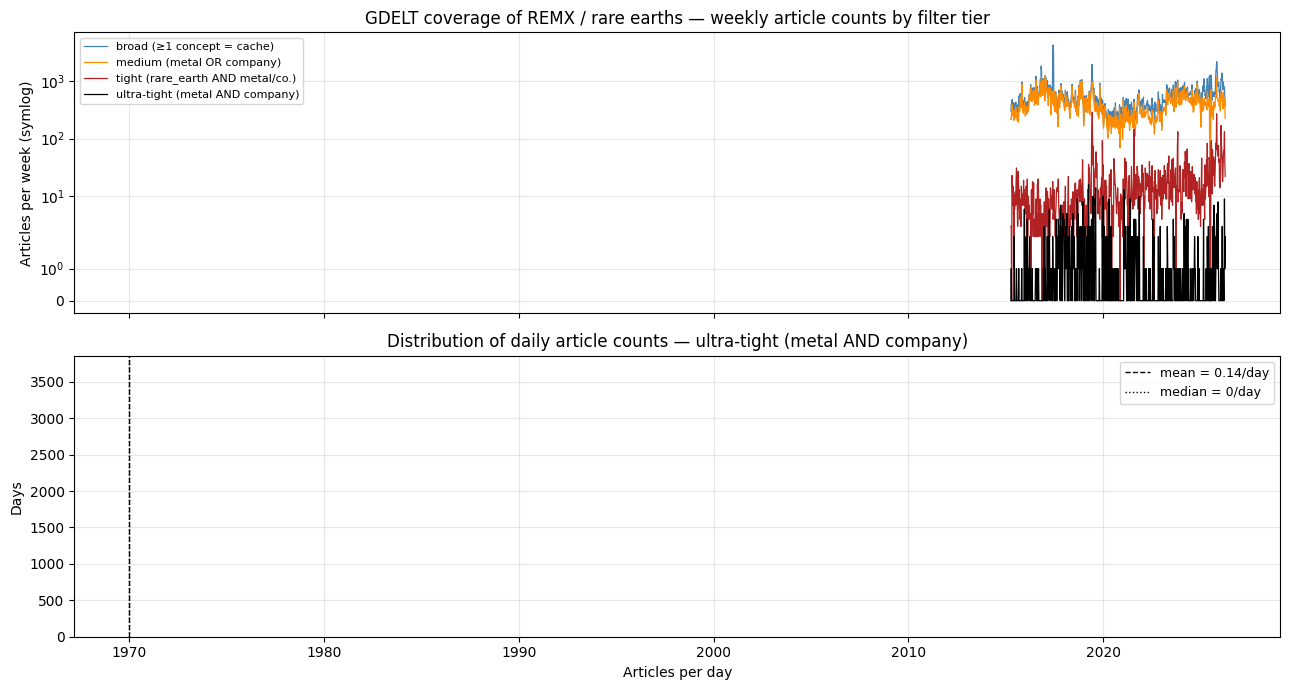

In [25]:
weekly = daily.resample('W').sum()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
colors = ['steelblue', 'darkorange', 'firebrick', 'black']

for c, col in zip(daily.columns, colors):
    axes[0].plot(weekly.index, weekly[c], lw=0.9, color=col, label=c)
axes[0].set_yscale('symlog')
axes[0].set_ylabel('Articles per week (symlog)')
axes[0].set_title('GDELT coverage of REMX / rare earths — weekly article counts by filter tier')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(alpha=0.3)

# Histogram of daily counts, ultra-tight tier
tight_col = 'ultra-tight (metal AND company)'
ax = axes[1]
counts = daily[tight_col].values
ax.hist(counts, bins=range(0, int(counts.max())+2),
         color='firebrick', edgecolor='white', alpha=0.85)
ax.axvline(counts.mean(), color='black', lw=1, linestyle='--',
            label=f'mean = {counts.mean():.2f}/day')
ax.axvline(np.median(counts), color='black', lw=1, linestyle=':',
            label=f'median = {np.median(counts):.0f}/day')
ax.set_xlabel('Articles per day')
ax.set_ylabel('Days')
ax.set_title(f'Distribution of daily article counts — {tight_col}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()